# **Python Class 16 – Seaborn & Plotly for Statistical Visualization**

In the previous lessons, we explored Pandas, data operations, missing values, and the basics of visualization using Matplotlib.
Now that you understand how data is structured and manipulated, it is time to level up your visualization skills.

Today’s class introduces two of the most powerful libraries for modern data visualization:

---

## **1. Seaborn – Statistical Visualization Made Simple**

Seaborn is built on top of Matplotlib, but it provides:

* beautiful default styles
* automatic statistical visualizations
* easier APIs for common analytic plots
* built-in support for Pandas DataFrames

You will learn how to create:

* **distributions** (histograms, KDEs)
* **joint plots** and **pair plots**
* **categorical comparisons** (boxplot, violin, swarmplot)
* **regression visualizations** (regplot, lmplot)

Seaborn is the tool of choice for **exploratory data analysis (EDA)** because it helps you quickly understand data patterns, relationships, and structure.

---

## **2. Plotly – Interactive Data Visualization**

Plotly takes visualization one step further by letting you create **interactive charts** that can:

* zoom
* pan
* display tooltips
* export as HTML
* embed in dashboards

You will learn the essential Plotly syntax for creating:

* line and scatter plots
* bar charts
* 3D plots
* interactive histograms
* marginal plots (Seaborn-like joint plots)

Plotly is especially useful for:

* dashboards
* presentations
* apps (Streamlit, Dash)
* exploratory analysis with large datasets

---

## **Why This Class Matters**

Understanding Seaborn and Plotly will allow you to:

* visualize complex relationships quickly
* communicate insights clearly
* build professional-grade visual reports
* prepare for real data science and analytics work
* create interactive analytics tools

Visualization is one of the most important skills in data analysis.
By the end of today’s class, you will be able to move beyond simple static plots and create charts that are **informative, aesthetic, and interactive**.

# Visualize with Seaborn
Matplotlib has proven to be an incredibly useful and popular visualization tool, but in cases when the task to be performed is becoming complicated, **Seaborn** helps.

Seaborn provides an API on top of Matplotlib that offers many choices for plot style and color defaults, defines simple high-level functions for common statistical plot types, and integrates with the functionality provided by Pandas DataFrames.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns
sns.set() # set the style in Seaborn

In [ ]:
rng = np.random.RandomState(0)
x = np.linspace(0, 10, 500)
y = np.cumsum(rng.randn(500, 6), 0)

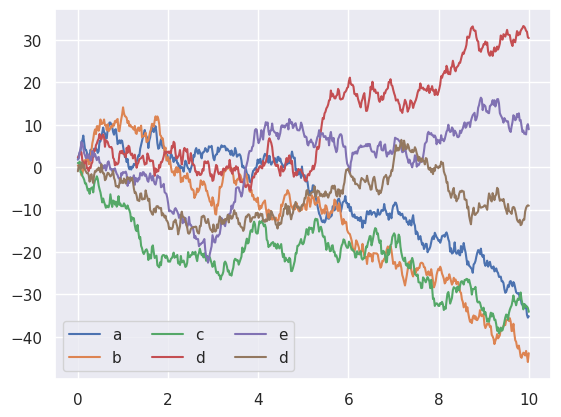

In [ ]:
plt.plot(x, y)
plt.legend('abcded', ncol=3, loc='lower left');

## Seaborn Plots
The main idea of Seaborn is that it provides high-level commands to create a variety of plot types useful for statistical data exploration, and even some statistical model fitting.

### Histograms, KDE, and densities
Often in statistical data visualization, all you want is to plot histograms and joint distributions of variables. We have seen that this is relatively straightforward in Matplotlib:

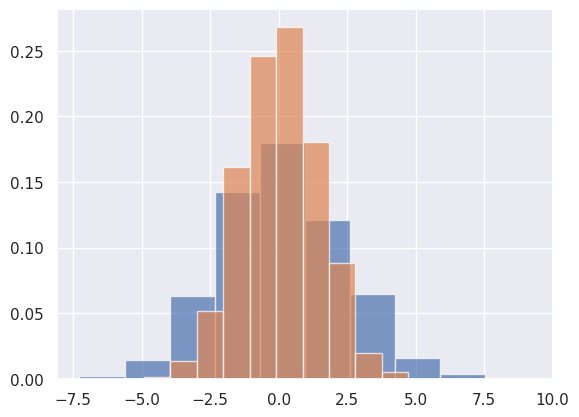

In [ ]:
data = np.random.multivariate_normal([0, 0],
                                     [[5, 2],
                                      [2, 2]], size=2000)
data = pd.DataFrame(data, columns=['x', 'y'])

for col in 'xy':
    plt.hist(data[col], density=True, alpha=0.7)

Rather than a histogram, we can get a smooth estimate of the distribution using a kernel density estimation, which Seaborn does with **sns.kdeplot**:

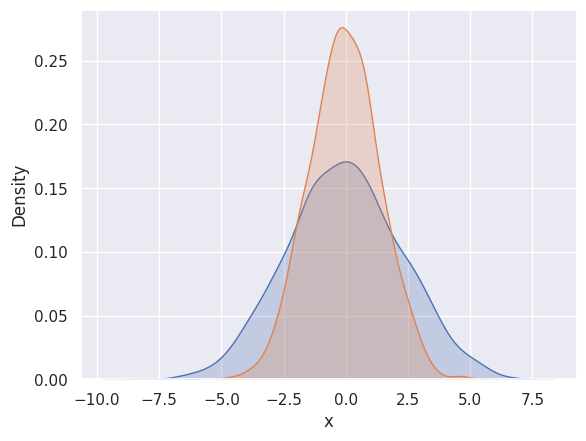

In [ ]:
for col in 'xy':
    sns.kdeplot(data[col], fill=True);

Histograms and KDE can be combined using **distplot**:

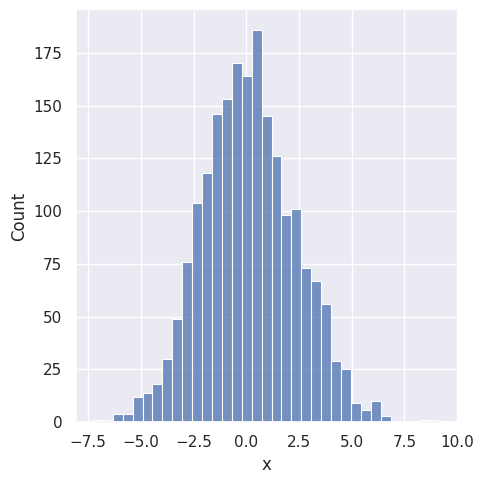

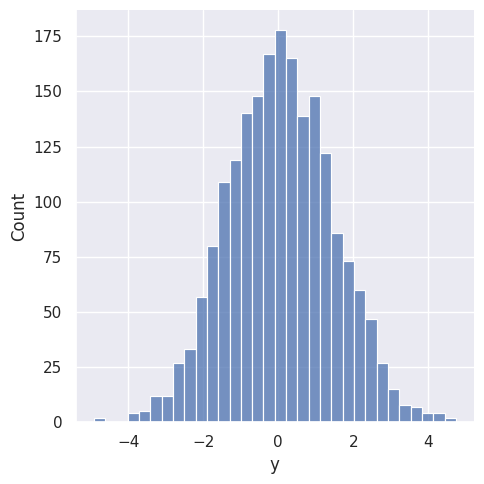

In [ ]:
sns.displot(data['x'])
sns.displot(data['y']);

We can alse get a two-dimensional visualization of the data:

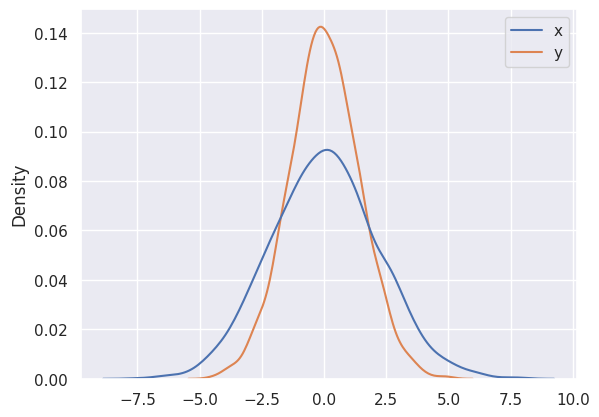

In [ ]:
sns.kdeplot([data['x'], data['y']]);

We can see the joint distribution and the marginal distributions together using **sns.jointplot**. For this plot, we'll set the style to a white background:

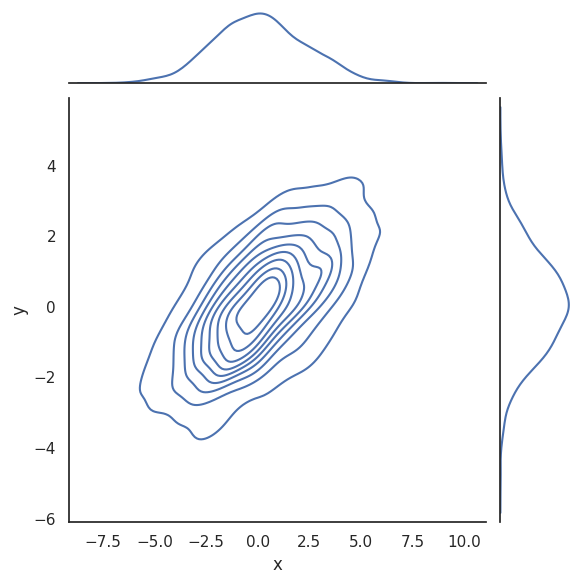

In [ ]:
with sns.axes_style('white'):
    sns.jointplot(x="x", y="y", data=data, kind='kde');

There are other parameters that can be passed to **jointplot** — for example, we can use a hexagonally based histogram instead:

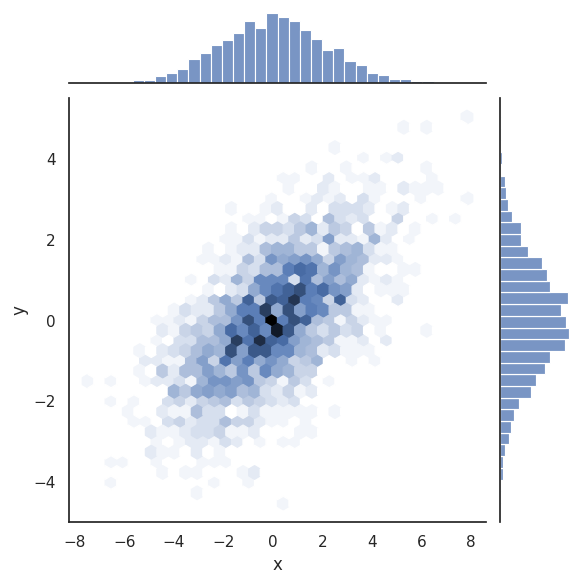

In [ ]:
with sns.axes_style('white'):
    sns.jointplot(x = "x", y = "y", data = data, kind='hex')

## Pair plots
Pair plots are a very useful for exploring correlations between multidimensional data, when you'd like to plot all pairs of values against each other.

We'll demo this with the well-known Iris dataset, which lists measurements of petals and sepals of three iris species:

In [ ]:
iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Visualizing the multidimensional relationships among the samples is as easy as calling **sns.pairplot**:

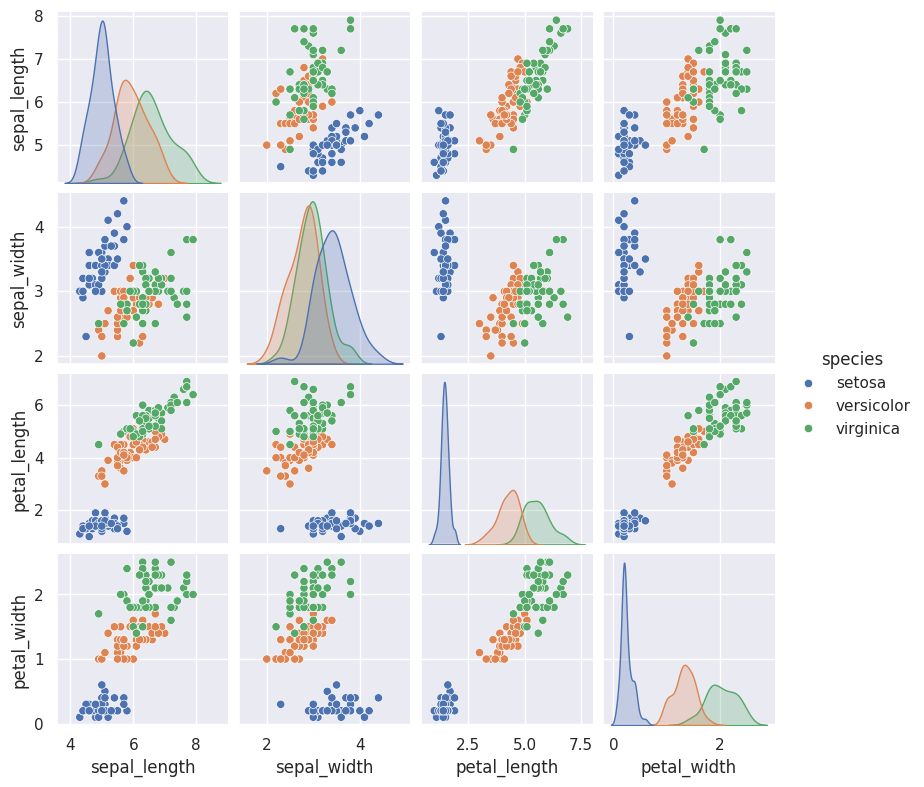

In [ ]:
sns.pairplot(iris, hue='species', height=2);

### Faceted histograms

Sometimes the best way to view data is via histograms of subsets. Seaborn's FacetGrid makes this extremely simple. We'll take a look at some data that shows the amount that restaurant staff receive in tips based on various indicator data:

In [ ]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


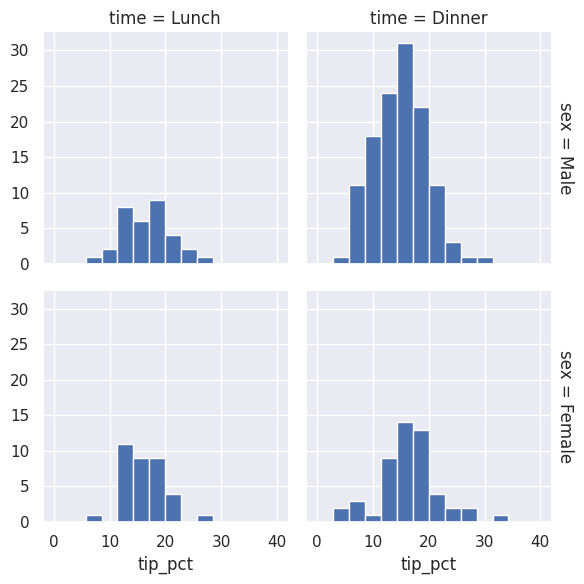

In [ ]:
tips['tip_pct'] = 100 * tips['tip'] / tips['total_bill']

grid = sns.FacetGrid(tips, row="sex", col="time", margin_titles=True)

grid.map(plt.hist, "tip_pct", bins=np.linspace(0, 40, 15));

## Heatmap

/tmp/ipython-input-3205055598.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tips_grouped = tips.pivot_table(index='day',


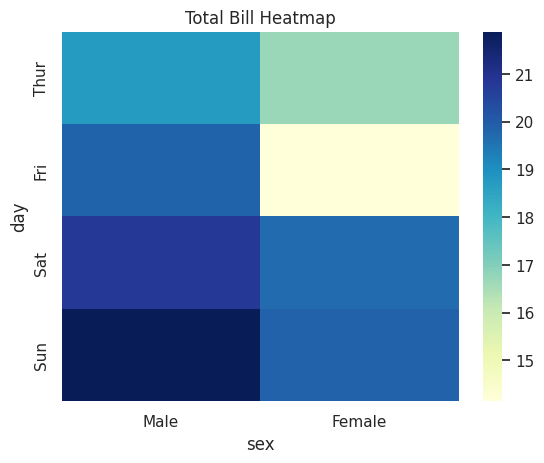

In [ ]:
tips_grouped = tips.pivot_table(index='day',
                                columns='sex',
                                values='total_bill')

plt.title('Total Bill Heatmap')
sns.heatmap(tips_grouped, cmap="YlGnBu");

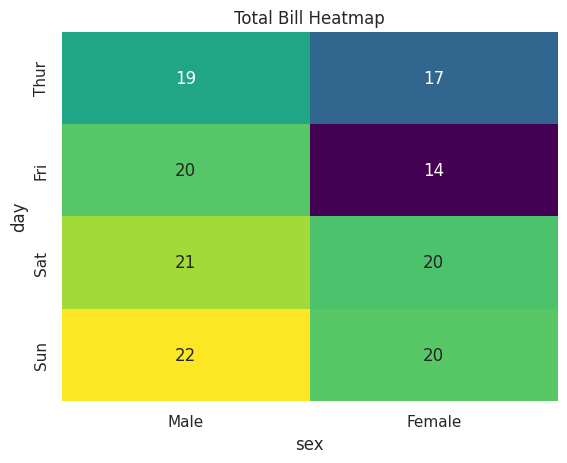

In [ ]:
# in case we want to display the actual values
# and hide the color bar
plt.title('Total Bill Heatmap')
sns.heatmap(tips_grouped, cmap="viridis",
            cbar=False, annot=True);

### Category plots
Category plots can be useful for this kind of visualization as well. This allows you to view the distribution of a parameter (with a `boxplot`) within bins defined by any other parameter:

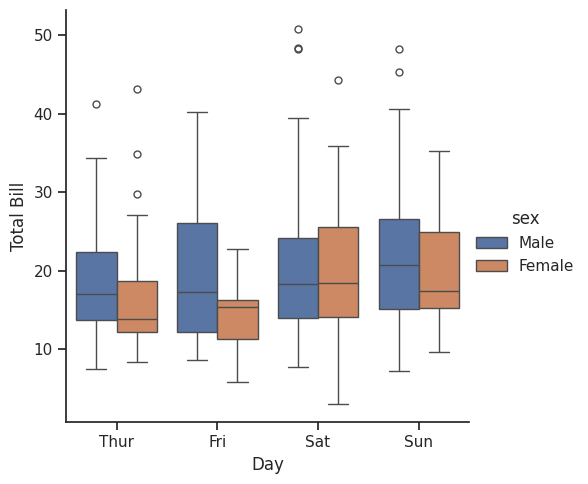

In [ ]:
with sns.axes_style(style='ticks'):
    g = sns.catplot(x="day", y="total_bill", hue="sex", data=tips, kind="box")
    g.set_axis_labels("Day", "Total Bill");

### Joint distributions
Similar to the pairplot we saw earlier, we can use sns.jointplot to show the joint distribution between different datasets, along with the associated marginal distributions:

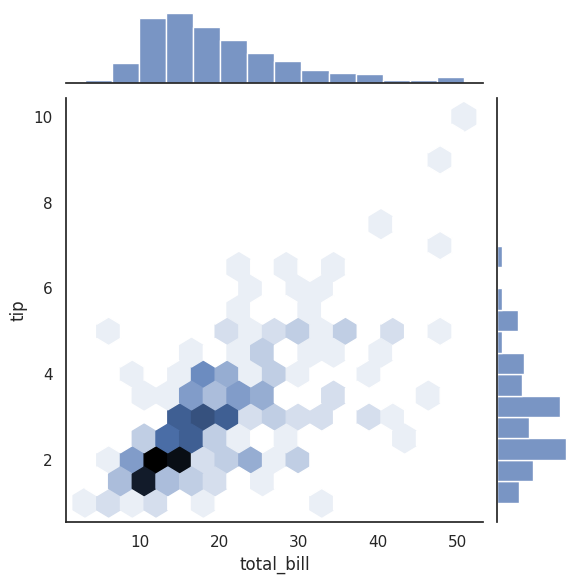

In [ ]:
with sns.axes_style('white'):
    sns.jointplot(x="total_bill", y="tip", data=tips, kind='hex')

The joint plot can even do some automatic kernel density estimation and regression:

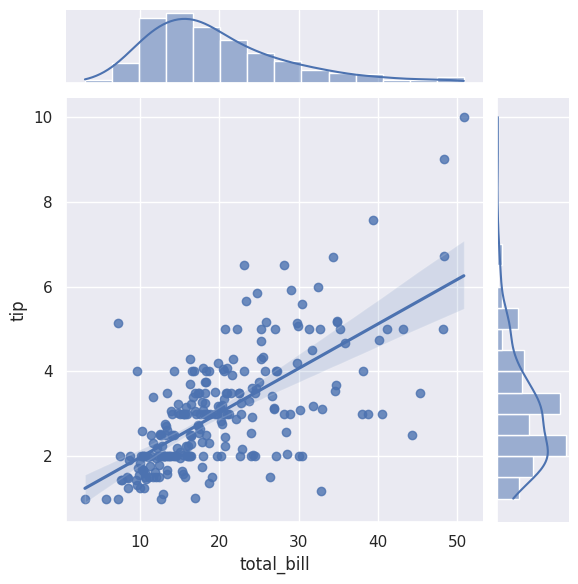

In [ ]:
sns.jointplot(x="total_bill", y="tip", data=tips, kind='reg');

### Bar plots
Time series can be plotted using **sns.catplot**. In the following example, we'll use the Planets data:

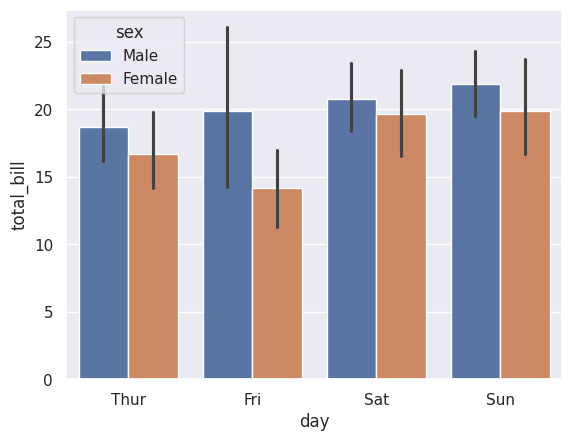

In [ ]:
ax = sns.barplot(x="day", y="total_bill", hue="sex", data=tips);

In [ ]:
planets = sns.load_dataset('planets')
planets.head()

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


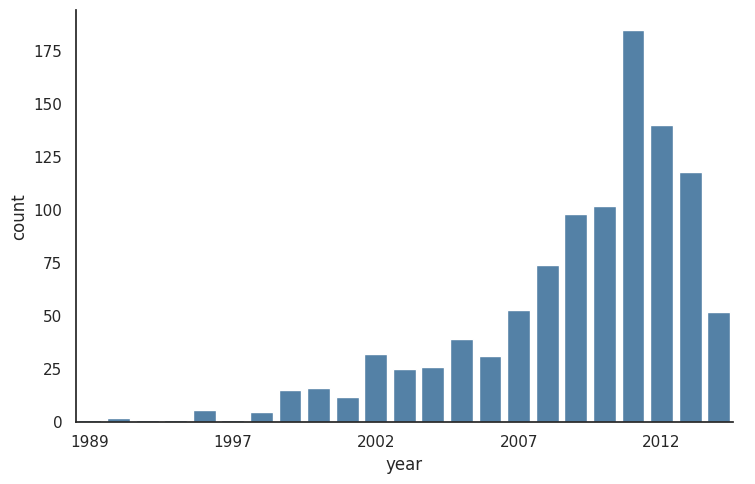

In [ ]:
with sns.axes_style('white'):
    g = sns.catplot(x="year", data=planets, aspect=1.5,
                       kind="count", color='steelblue')
    g.set_xticklabels(step=5)

We can learn more by looking at the method of discovery of each of these planets:

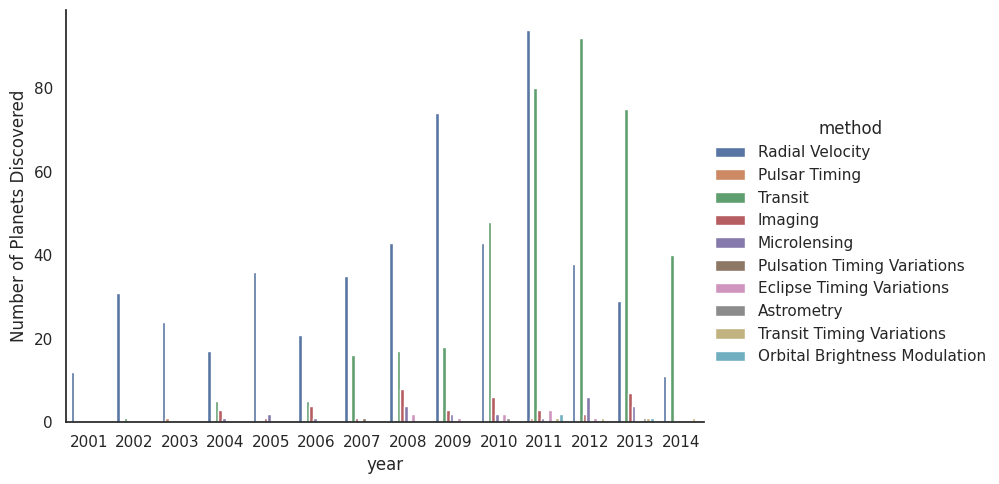

In [ ]:
# change the size of this plot
with sns.axes_style('white'):
    g = sns.catplot(x="year", data=planets, aspect=1.5, kind='count',
                       hue='method', order=range(2001, 2015))
    g.set_ylabels('Number of Planets Discovered')
# plt.yscale('log')

# Visualize with Plotly

`Plotly` makes interactive, publication-quality graphs and animations. [Here](https://plot.ly/python/) you can find some example graphs with their code. Let's have a look at a few examples here.

Plotly charts are described declaratively with objects in `plotly.graph_objects` and `dict`. Every aspect of a plotly chart (colors, grids, data etc) has a corresponding `key-value` attribute in these objects. [This page](https://plot.ly/python/reference/) contains an extensive list of these attributes.

Plotly's graph description places attributes into two categories:

* traces (objects that describe a single series of data in a graph like Scatter or Heatmap)
* layout attributes that apply to the rest of the chart, like the title, xaxis, or annotations).

Here is a simple example of a plotly chart.

In [ ]:
import plotly.graph_objects as go

fig = go.Figure([
    go.Scatter(
        x=[1, 2, 3],
        y=[3, 1, 6],

        marker=dict(
            color="rgb(16, 32, 77)"
        )
    ),
    go.Bar(
        x=[1, 2, 3],
        y=[3, 1, 6],
        name="bar chart example"
    )
])

fig.update_layout(
    title="Simple example",
    width=800,
    height=550,
    xaxis=dict(
        title="time"
    )
)

fig.show()

Hover over the above plot to see what we mean by saying an interactive plot.

In [ ]:
import numpy as np

In [ ]:
N = 1_000
random_x = np.linspace(0, 1, N)
random_y0 = np.random.randn(N) + 5
random_y1 = np.random.randn(N)
random_y2 = np.random.randn(N) - 5

fig = go.Figure()

# Add traces
fig.add_trace(go.Scatter(x=random_x, y=random_y0,
                    mode='markers',
                    name='markers'))
fig.add_trace(go.Scatter(x=random_x, y=random_y1,
                    mode='lines+markers',
                    name='lines+markers'))
fig.add_trace(go.Scatter(x=random_x, y=random_y2,
                    mode='lines',
                    name='lines'))

fig.update_layout(title='Another example', width=800, height=400)

fig.show()

Now let's make an animation with `Plotly`.

In [ ]:
f = lambda u: u ** 2
x = np.linspace(-10, 10, 100)
y = f(x)

x_min = min(x)
x_max = max(x)


# Create figure
fig = go.Figure(
    data=[
          go.Scatter(x=x, y=y,
                     mode="lines",
                     name="",
                     line=dict(width=2, color="blue")
                     ),
          go.Scatter(x=x, y=y,
                     name="curve",
                     mode="lines",
                     line=dict(width=2, color="blue"))
          ],
    frames=[go.Frame(
        data=[go.Scatter(x=x, y=f(k) + 2 * k * (x - k),
                    mode='lines',
                    name='tangent line',
                    line={"color": 'red'})
        ]) for k in x]
)

fig.update_layout(
    width=600, height=600,
    title="Tangent Line Over a Curve",
    xaxis=dict(range=[x_min, x_max]),
    yaxis=dict(range=[-10, f(x_max)]),
    transition_duration=0,
    updatemenus=[
                dict(type="buttons",
                      buttons=[
                              dict(label="Play",
                                    method="animate",
                                    args=[None,
                                          dict(
                                              frame={"duration": 100}
                                               )
                                          ]
                                   ),
                              dict(label='Pause',
                                   method='animate',
                                   args=[[None],
                                         dict(frame={
                                             "duration": 0,
                                             "redraw": False
                                             },
                                              mode='immediate',
                                              transition={'duration': 0})]
                                   )
                              ]
                     )
                ]
                )


fig.show()

Press `Play` in the above graph to see the animation.

# Visualize images


There are common benchmark datasets used by the machine learning community, which can be downloaded from the ML packages such as `sklearn`. Some of those datasets are related to images. Let's plot some of the images from well known image datasets.

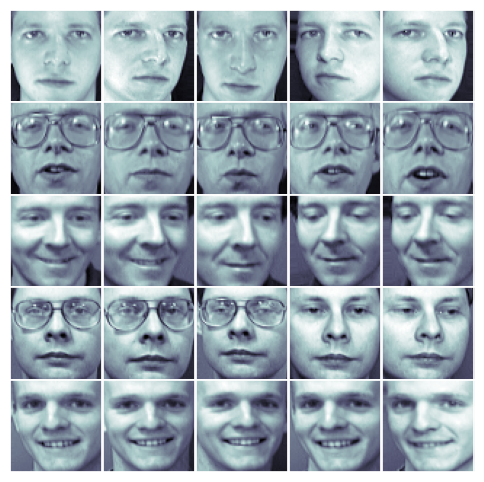

In [ ]:
fig, ax = plt.subplots(5, 5, figsize=(6, 6))
fig.subplots_adjust(hspace=0, wspace=0)
# Get some face data from scikit-learn
from sklearn.datasets import fetch_olivetti_faces
faces = fetch_olivetti_faces().images
for i in range(5):
  for j in range(5):
    ax[i, j].xaxis.set_major_locator(plt.NullLocator())
    ax[i, j].yaxis.set_major_locator(plt.NullLocator())
    ax[i, j].imshow(faces[10 * i + j], cmap="bone")

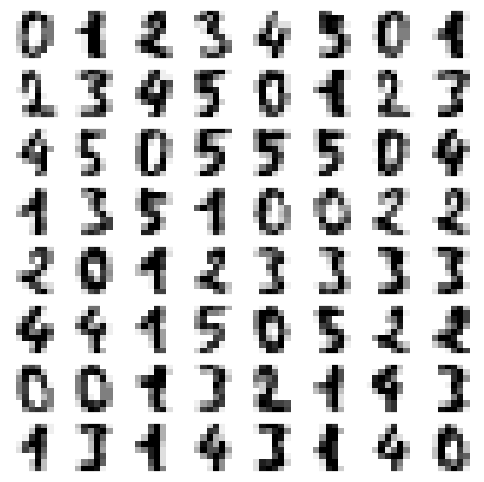

In [ ]:
from sklearn.datasets import load_digits
digits = load_digits(n_class=6)
fig, ax = plt.subplots(8, 8, figsize=(6, 6))
for i, axi in enumerate(ax.flat):
  axi.imshow(digits.images[i], cmap='binary')
  axi.set(xticks=[], yticks=[])

Images are just numbers

In [ ]:
digits.images[0]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

As we can see this is the number zero: 0

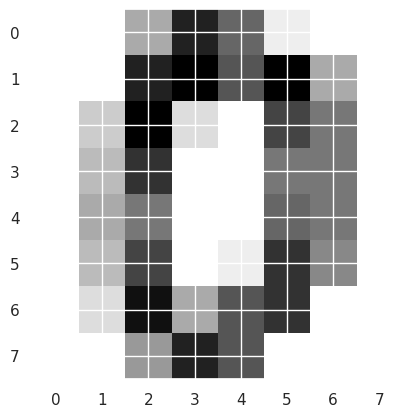

In [ ]:
plt.imshow(digits.images[0], cmap='binary')

# Visualize Gradient Descent

In [ ]:
def gradient_descent(grad_f, x0, tol=0.01, alpha=0.05):
  if len(x0) == 1:
    plot_points = lambda x, y: plt.plot(x, g(x), marker='.', color=y)
  else:
    plot_points = lambda x, y: plt.plot(x[0], x[1], marker='.', color=y)

  x = x0
  nr_iterations = 1
  while np.linalg.norm(grad_f(x0)) > tol:
    nr_iterations += 1
    plot_points(x0, 'red')
    x = x0 - alpha * grad_f(x0)
    x0 = x
  plot_points(x0, 'k')
  print(f'The algorithm converged in {nr_iterations} steps!')
  return x

## Function with one variable

$$g(x) = \begin{cases} -cos(\pi x), \text{if } x \leq 1 \\
(x-2)^2, \text{if } x > 1
\end{cases}
$$

In [ ]:
def g(x):
  return -np.cos(x * np.pi) * (x <= 1) + (x-2) ** 2 * (x > 1)

def grad_g(x):
  return (x <= 1) * np.pi * np.sin(x * np.pi) + (x > 1) * 2 * (x-2)

The algorithm converged in 62 steps!


array([2.00485193])

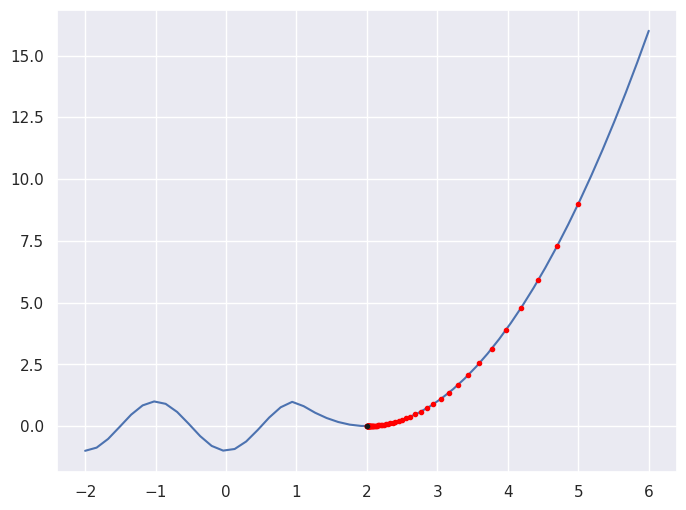

In [ ]:
x = np.linspace(-2, 6, 50)
y = g(x)
plt.figure(figsize=(8, 6))
plt.plot(x, y);
gradient_descent(grad_g, np.array([5]), alpha=0.05)

## Function with two variables

In [ ]:
def f(x):
  # x = (x_1, x_2), so that f:R^2 -> R
  return np.sin(x[0]) ** 10 + np.cos(10 + x[1] * x[0] ) * np.cos(x[0])

def grad_f(x):
  u = 10 + x[1] * x[0]
  fx1 = 10 * np.sin(x[0])**9-np.sin(u)*x[1]*np.cos(x[0])-np.sin(x[0])*np.cos(u)
  fx2 = -np.cos(x[0]) * x[0] * np.sin(u)
  return np.array([fx1, fx2])

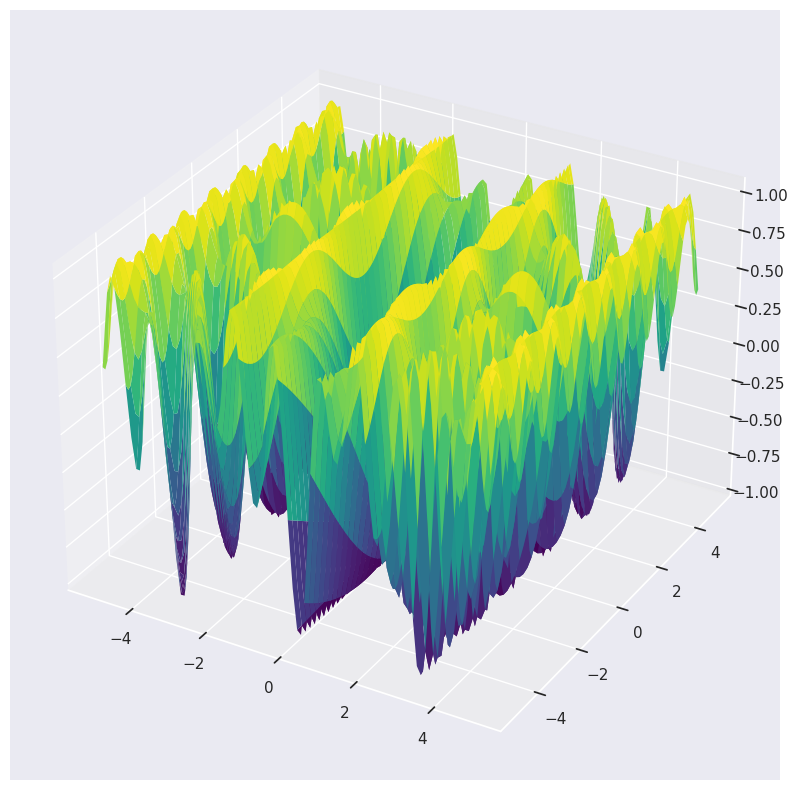

In [ ]:
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)

X, Y = np.meshgrid(x, y)
Z = f(np.array([X, Y]))

plt.figure(figsize=(10, 10))
ax = plt.axes(projection='3d')
ax.plot_surface(X,Y,Z, cmap='viridis', edgecolor='none');

The algorithm converged in 512 steps!


array([-0.1733493 ,  2.98068086])

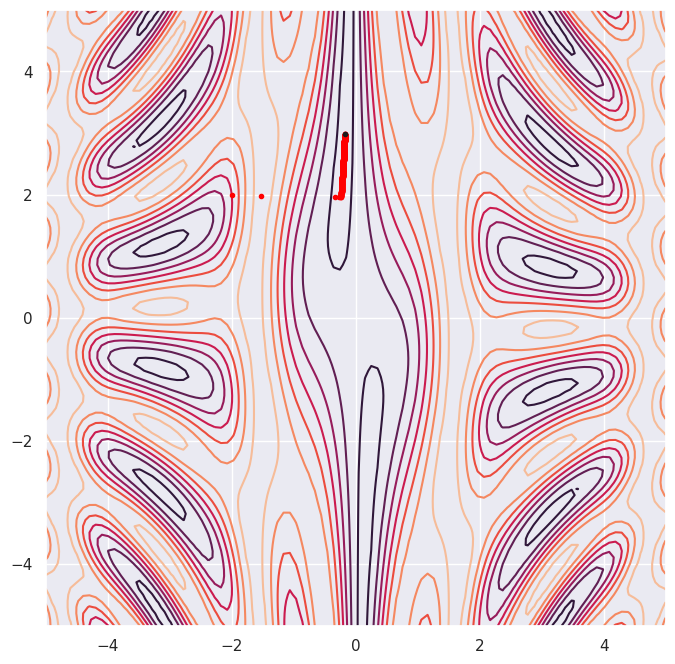

In [ ]:
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)

X, Y = np.meshgrid(x, y)
Z = f(np.array([X, Y]))

plt.figure(figsize=(8,8))
plt.contour(X, Y, Z);
gradient_descent(grad_f, np.array([-2, 2]), alpha=0.13)